In [1]:
import sys
sys.path.append('../benchmarking/prediction_utils')
from ponq_eval import *
import matplotlib.pyplot as plt

In [2]:


def get_cd_f1_nc(gt_mesh, pred_mesh):

    # load gt
    # chnage: gt_mesh = trimesh.load(gt_obj_name)
    
    gt_mesh.vertices[:] /= 2 #scale_gt
    
    # add: nomralization
    # gt_mesh.vertices[:] = eval_normalization(gt_mesh.vertices)

    gt_points, gt_indexs = gt_mesh.sample(sample_num, return_index=True)
    gt_normals = gt_mesh.face_normals[gt_indexs]
    
    # load pred
    # chnage: pred_mesh = trimesh.load(pred_obj_name, force='mesh')
    
    try:
        # pred_mesh.vertices[:] = eval_normalization(
        #     pred_mesh.vertices)
        # pred_mesh.vertices[:] = pred_mesh.vertices[:] - 0.5
        pred_mesh.vertices[:] = pred_mesh.vertices[:] /2
        pred_points, pred_indexs = pred_mesh.sample(
            sample_num, return_index=True)
        # pred_points = eval_normalization(pred_points)
        pred_normals = pred_mesh.face_normals[pred_indexs]
    except:
        print('\n\n\n WARNING \n\n\n')
        pred_points = np.zeros((1, 3))
        pred_mesh = trimesh.Trimesh(pred_points, np.array([]))
        pred_normals = np.zeros((1, 3))

    # cd and nc and f1

    # from gt to pred
    pred_tree = KDTree(pred_points)
    dist, inds = pred_tree.query(gt_points, k=1)
    recall = np.sum(dist < f1_threshold) / float(len(dist))
    gt2pred_mean_cd1 = np.mean(dist)
    dist = np.square(dist)
    gt2pred_mean_cd2 = np.mean(dist)
    neighbor_normals = pred_normals[np.squeeze(inds, axis=1)]
    dotproduct = np.abs(np.sum(gt_normals*neighbor_normals, axis=1))
    gt2pred_nc = np.mean(dotproduct)

    # from pred to gt
    gt_tree = KDTree(gt_points)
    dist, inds = gt_tree.query(pred_points, k=1)
    precision = np.sum(dist < f1_threshold) / float(len(dist))
    pred2gt_mean_cd1 = np.mean(dist)
    dist = np.square(dist)
    pred2gt_mean_cd2 = np.mean(dist)
    neighbor_normals = gt_normals[np.squeeze(inds, axis=1)]
    dotproduct = np.abs(np.sum(pred_normals*neighbor_normals, axis=1))
    pred2gt_nc = np.mean(dotproduct)

    cd1 = gt2pred_mean_cd1+pred2gt_mean_cd1
    cd2 = gt2pred_mean_cd2+pred2gt_mean_cd2
    nc = (gt2pred_nc+pred2gt_nc)/2
    if recall+precision > 0:
        f1 = 2 * recall * precision / (recall + precision)
    else:
        f1 = 0

    if True:
        gt_edge_points = uniform_edge_sampling(
            gt_mesh, e_angle_treshold, e_sampling_N)

        pred_edge_points = uniform_edge_sampling(
            pred_mesh, e_angle_treshold, e_sampling_N)
        if len(pred_edge_points) == 0:
            pred_edge_points = np.zeros([486, 3], np.float32)
        if len(gt_edge_points) == 0:
            ecd1, ecd2 = 0, 0
            ef1 = 1
        else:
            # from gt to pred
            tree = KDTree(pred_edge_points)
            dist, inds = tree.query(gt_edge_points, k=1)
            erecall = np.sum(dist < ef1_threshold) / float(len(dist))
            gt2pred_mean_ecd1 = np.mean(dist)
            dist = np.square(dist)
            gt2pred_mean_ecd2 = np.mean(dist)

            # from pred to gt
            tree = KDTree(gt_edge_points)
            dist, inds = tree.query(pred_edge_points, k=1)
            eprecision = np.sum(dist < ef1_threshold) / float(len(dist))
            pred2gt_mean_ecd1 = np.mean(dist)
            dist = np.square(dist)
            pred2gt_mean_ecd2 = np.mean(dist)

            ecd1 = gt2pred_mean_ecd1+pred2gt_mean_ecd1
            ecd2 = gt2pred_mean_ecd2+pred2gt_mean_ecd2
            if erecall+eprecision > 0:
                ef1 = 2 * erecall * eprecision / (erecall + eprecision)
            else:
                ef1 = 0

        return 0, cd1, cd2, f1, nc, ecd2, ef1


In [3]:
i=1

scales = [1, 2, 4, 8, 16]
res = []
for i in scales:
    src_mesh = trimesh.load('../../data/GT_thingi/68380.obj')
    pred_mesh = trimesh.load(f'horse_fac/68380_{i}.obj')
    res.append(get_cd_f1_nc(src_mesh, pred_mesh))

In [4]:
cds = [r[2]*1e5 for r in res]
ncs = [r[4] for r in res]

In [23]:
cds

[3.8607299212369606,
 2.0477005426891086,
 1.7740324630063007,
 1.7465916195202362,
 1.7546720199083277]

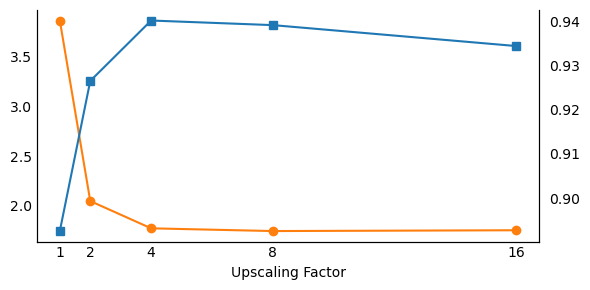

In [22]:
fig, ax1 = plt.subplots(figsize=(6, 3))

# Plot cds on left axis
ax1.plot(scales, cds, '-o', label='CD2', color='tab:orange')
ax1.set_xlabel('Upscaling Factor')
ax1.set_xticks(scales)
# ax1.set_xticklabels([f'x{e}' for e in scales])
# ax1.set_ylabel('Chamfer Distance', color='tab:orange')
ax1.tick_params(axis='y', length=0)
ax1.tick_params(axis='x', length=0)

ax1.spines[['top']].set_visible(False)


# Create second y-axis for ncs
ax2 = ax1.twinx()
ax2.plot(scales, ncs, '-s', label='NC', color='tab:blue')
# ax2.set_ylabel('Normal Consistency', color='tab:blue')
ax2.spines[['top']].set_visible(False)

ax2.tick_params(axis='y', right=False)

# plt.title('CD2 and NC vs Scale')
fig.tight_layout()
plt.savefig('horse_fac_eval.pdf')
plt.show()


### Timings

In [2]:

import matplotlib.pyplot as plt

In [3]:
grid = [32, 64, 128]

rfta = [25, 106.3461, 1095.9089]
ponq = [0.9744, 5.8731, 56.6631]
ours = [0.7639, 1.1250, 2.7782]

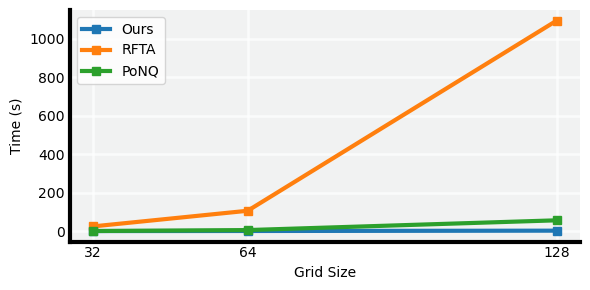

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_facecolor('#F1F2F2')
# fig.patch.set_facecolor('#555555')
# Plot cds on left axis
lw = 3

ax.plot(grid, ours, '-s', label='Ours', linewidth=lw)
ax.plot(grid, rfta, '-s', label='RFTA', linewidth=lw)
ax.plot(grid, ponq, '-s', label='PoNQ', linewidth=lw)

ax.set_xticks(grid)
# ax.set_yscale('log')
ax.set_xlabel('Grid Size')
ax.set_ylabel('Time (s)')

# ax1.set_xticklabels([f'x{e}' for e in scales])
# ax1.set_ylabel('Chamfer Distance', color='tab:orange')
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=0)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(
    True,
    which='both',
    axis='both',
    linestyle='-',
    linewidth=lw/1.61,
    color="#ffffff",
    alpha=0.7
)
for spine in ax.spines.values():
    spine.set_linewidth(lw)


# Create second y-axis for ncs

# plt.title('CD2 and NC vs Scale')
plt.legend()
fig.tight_layout()
plt.savefig('timings.pdf')
plt.show()
